# 5) Testing Semisupervised Model
- We will combine the training PSIC and MTG data from the deployed model and measure performance

## Library Imports

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

## Uploading Datasets

In [2]:
# uploading pseudolabelled MTGs
mtg_200 = pd.read_csv("jamendo_pseudolabeled200_402.csv")

# uploading psic data
psic = pd.read_excel("combine_450inputs.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: 'jamendo_pseudolabeled200_402.csv'

In [3]:
# Double Checking shapes
psic.shape

(3839, 402)

In [4]:
mtg_200.shape

(200, 402)

## Combining Data

In [5]:
full_200 = pd.concat([psic, mtg_200], axis=0, ignore_index=True)
full_200.shape

(4039, 402)

In [6]:
# splitting features and target for refitting
X_200 = full_200.drop('depth', axis=1)
y_200 = full_200['depth']


X_train200, X_test200, y_train200, y_test200 = train_test_split(X_200, y_200, test_size=0.2, random_state=12345)

## ML

### With 50 pseudolabels
- Ran once, then skipped with 200 pseudolabels

In [7]:
# # Define XGBRegressor model parameters
# params = {
#     'objective': 'reg:squarederror',
#     'max_depth': 3,
#     'learning_rate': 0.1,
#     'n_estimators': 100,
#     'subsample': 0.8,
#     'colsample_bytree': 0.8,
#     'random_state': 42
# }

# # Instantiate XGBRegressor with the parameters
# xgb = xgb.XGBRegressor(**params)

# # Train the model
# xgb.fit(X_train50, y_train50)

In [8]:
# # metrics
# r_2 = r2_score(y_test, predictions50)
# mse = mean_squared_error(y_test, predictions50)
# rmse = rmse = np.sqrt(mse)
# mae = mean_absolute_error(y_test, predictions50)

# # table
# df = pd.DataFrame({
#     "Metric": ["R²", "RMSE", "MAE"],
#     "Model": [r_2, rmse, mae],
# })

# # format
# df["Model"] = df["Model"].map(lambda x: f"{x:.3f}")

# print(df.to_string(index=False))

### With 200 Pseudolabels

In [9]:
# Define XGBRegressor model parameters
params = {
    'objective': 'reg:squarederror',
    'max_depth': 3,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

# Instantiate XGBRegressor with the parameters
xgb = xgb.XGBRegressor(**params)

# Train the model
xgb.fit(X_train200, y_train200)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [10]:
# prediction
predictions200 = xgb.predict(X_test200)

In [11]:
# metrics
r_2 = r2_score(y_test200, predictions200)
mse = mean_squared_error(y_test200, predictions200)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test200, predictions200)
pcc, _ = pearsonr(y_test200, predictions200)

# table
df = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE", "PCC"],
    "Model": [r_2, rmse, mae, pcc],
})

# formatting
df["Model"] = df["Model"].map(lambda x: f"{x:.3f}")

print(df.to_string(index=False))

Metric Model
    R² 0.522
  RMSE 0.163
   MAE 0.126
   PCC 0.725


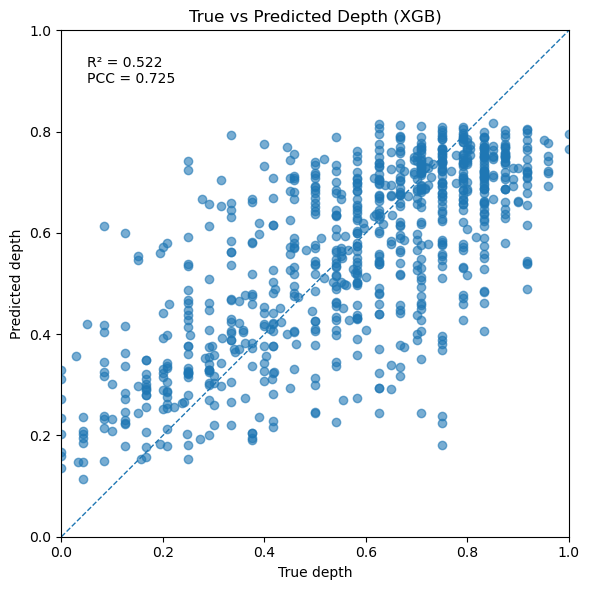

In [12]:
# Plotting R_2 and PCC scores

plt.figure(figsize=(6, 6))
plt.scatter(y_test200, predictions200, alpha=0.6)

# 45° reference line
lims = [
   np.min([np.min(y_test200), np.min(predictions200)]),
    np.max([np.max(y_test200), np.max(predictions200)])
]
plt.plot(lims, lims, "--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("True depth")
plt.ylabel("Predicted depth")
plt.title("True vs Predicted Depth (XGB)")

# Annotate metrics
plt.text(
    0.05, 0.95,
    f"R² = {r_2:.3f}\nPCC = {pcc:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

# saving as JPEG
plt.savefig("true_pred_pseudoXGB.jpg",
            dpi=300,
            bbox_inches="tight")

plt.tight_layout()
plt.show()

In [13]:
importances   = xgb.feature_importances_
feature_names = X_train200.columns.to_list()

feat_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
})

print(feat_df)

                  feature  importance
0    spectral bandwidth 1    0.018874
1    spectral bandwidth 2    0.001238
2    spectral bandwidth 3    0.006385
3    spectral bandwidth 4    0.000599
4    spectral bandwidth 5    0.005288
..                    ...         ...
396            tonnetz 47    0.003535
397            tonnetz 48    0.010308
398            tonnetz 49    0.000000
399            tonnetz 50    0.000000
400                 tempo    0.004179

[401 rows x 2 columns]


In [14]:
def feature_group(name: str) -> str:
    if name.startswith("MFCCs"):
        return "MFCCs (PCA)"
    if name.startswith("chromagram"):
        return "Chromagram (PCA)"
    if name.startswith("spectral centroid"):
        return "Spectral centroid (PCA)"
    if name.startswith("spectral bandwidth"):
        return "Spectral bandwidth (PCA)"
    if name.startswith("spectral contrast"):
        return "Spectral contrast (PCA)"
    if name.startswith("spectral flatness"):
        return "Spectral flatness (PCA)"
    if name.startswith("spectral rolloff"):
        return "Spectral rolloff (PCA)"
    if name.startswith("tonnetz"):
        return "Tonnetz (PCA)"
    if name == "tempo":
        return "Tempo"
    return "Other"   # just in case

In [15]:
feat_df["group"] = feat_df["feature"].apply(feature_group)

group_imp = (
    feat_df
    .groupby("group")["importance"]
    .sum()
    .sort_values(ascending=False)
)

# Optionally convert to percentages
group_imp_pct = 100 * group_imp / group_imp.sum()
print(group_imp_pct)

group
Spectral contrast (PCA)     18.501440
Spectral flatness (PCA)     15.581136
Tonnetz (PCA)               12.973110
Chromagram (PCA)            12.710357
Spectral bandwidth (PCA)    11.726398
MFCCs (PCA)                 10.680145
Spectral centroid (PCA)      9.782568
Spectral rolloff (PCA)       7.626906
Tempo                        0.417941
Name: importance, dtype: float32


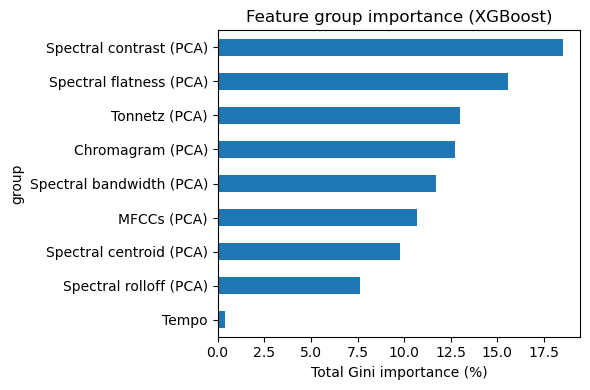

In [16]:
plt.figure(figsize=(6, 4))
group_imp_pct.plot(kind="barh")
plt.xlabel("Total Gini importance (%)")
plt.title("Feature group importance (XGBoost)")
plt.gca().invert_yaxis()
plt.tight_layout()

# saving as JPEG
plt.savefig("pseudolabel_feature_importance.jpg",
            dpi=300,
            bbox_inches="tight")

plt.show()